# Introduction

Here is introduction to time series modeling. 

In the broadest sense, a time series model is simply a model that explicitly includes time. "Including time", of course, can mean lots of things. For example, we might literally put time into the model as a feature. Calling our variable of interest $y_t$, we might say that $y_t$ follows a *deterministic trend*, or:

$$ y_t = \alpha + \beta t + \varepsilon_t $$

In [7]:
import sys

if "google.colab" in sys.modules:
    !pip install git+https://github.com/pymc-devs/pymc-extras.git@main
    !pip install nutpie
    !pip install watermark

import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import xarray as xr  # <-- needed for type checking

warnings.filterwarnings(action="ignore", category=UserWarning)

plt.rcParams.update(
    {
        "figure.figsize": (14, 4),
        "figure.dpi": 144,
        "axes.grid": True,
        "grid.linewidth": 0.5,
        "grid.linestyle": "--",
        "axes.spines.top": False,
        "axes.spines.bottom": False,
        "axes.spines.left": False,
        "axes.spines.right": False,
    }
)


SEED = sum(map(ord, "Intro to Statespace"))
rng = np.random.default_rng(SEED)

## Simple Linear State-Space Model (SSM)

This code sets up a Bayesian state-space model (SSM) in PyMC where we're simulating a deterministic linear trend in time-series data. Instead of starting with real data, we're generating fake data from the prior predictive distribution.

We’ve built a simple **linear SSM** where observations follow a Gaussian distribution around a linear trend:

$$
y_t \sim \mathcal{N}(\alpha + \beta t,\ \sigma^2)
$$

**Interpretation**

- $\alpha$: baseline level at time $t=0$  
- $\beta$: slope over time  
- $\sigma$: noise (observation variability)  
- $y_t$: observed or simulated data at time $t$

Right now, the trend $\mu_t = \alpha + \beta t$ is **deterministic** (a straight line), while the observations are **random** due to the Gaussian noise $\sigma$.


### How this fits into SSMs?


**Observation equation**
$$
y_t = \mu_t + \varepsilon_t,\qquad \varepsilon_t \sim \mathcal{N}(0,\ \sigma^2)
$$

**State equation (stochastic trend)**
$$
\mu_t = \mu_{t-1} + \eta_t,\qquad \eta_t \sim \mathcal{N}(0,\ \tau^2)
$$

Making the state equation stochastic turns the trend $\mu_t$ into a **Gaussian Random Walk**.  
Here, $\tau^2$ controls how much the latent state can drift between time steps.





## Forecasting

Sampling: [alpha, beta, sigma, y_hat]


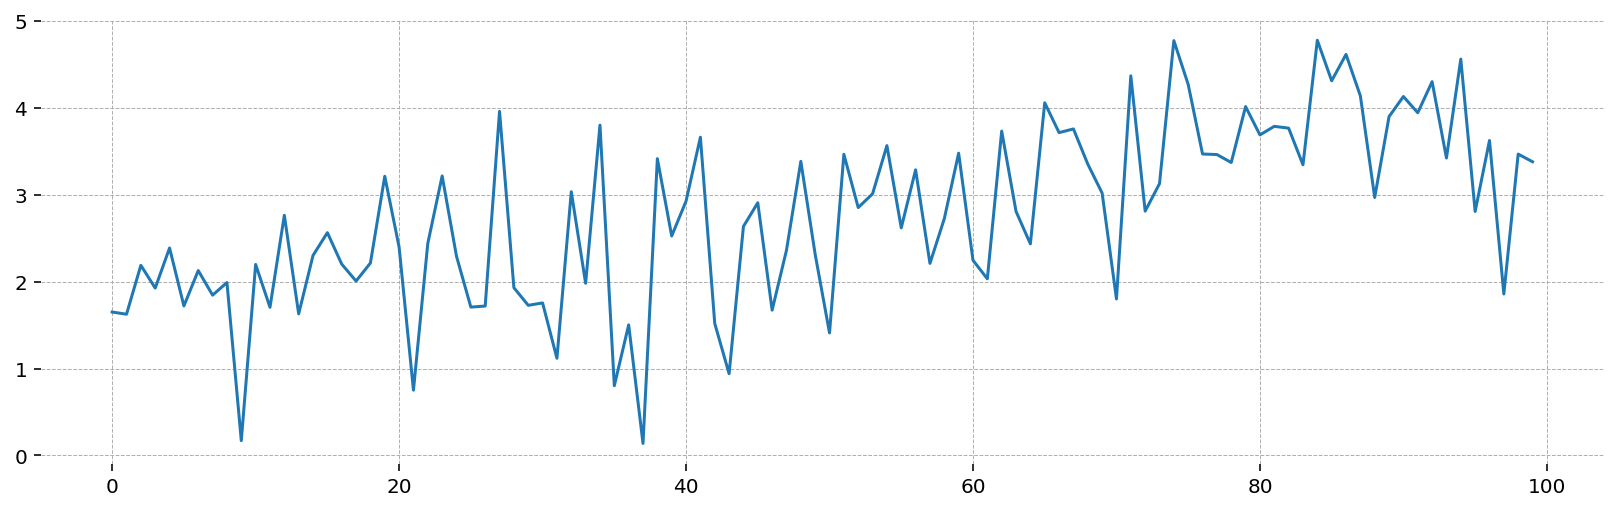

In [2]:
coords = {"time": range(100)}
with pm.Model(coords=coords) as deterministic_trend:
    t = pm.Data("t", range(100), dims=["time"])
    alpha = pm.Normal("alpha", mu=3, sigma=1)
    beta = pm.HalfNormal("beta", sigma=0.1)
    mu = pm.Deterministic("mu", alpha + beta * t, dims=["time"])

    sigma = pm.Exponential("sigma", 1)
    y_hat = pm.Normal("y_hat", mu=mu, sigma=sigma, dims=["time"])
    prior = pm.sample_prior_predictive(draws=1, random_seed=rng)

data = prior.prior.y_hat.values.squeeze()
plt.plot(data);

In [4]:
# We're using PyMC’s pm.observe context manager to reuse an existing model 
# (deterministic_trend) but this time attach data to the variable 
# y_hat so you can actually perform inference.

with pm.observe(
    deterministic_trend, {"y_hat": prior.prior.y_hat.values.squeeze()}
) as deterministic_trend_obs:
    idata = pm.sample(compile_kwargs={"mode": "NUMBA"}, random_seed=rng)
    idata = pm.sample_posterior_predictive(
        idata, extend_inferencedata=True, random_seed=rng
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.
Sampling: [y_hat]


Output()

The types of things you want to do with a time series models are sometimes different from what is done with a "normal" model. For one, we want to be able to say something about the future. Time-as-feature models are attractive, because it is trivial to know the future values of the time variable: it marches forward. We can directly replace the training time with an out-of-sample time and generate forecasts.

In [ ]:
# Forecasting future values with your PyMC state-space model after you’ve already fitted it

with deterministic_trend_obs:
    pm.set_data({"t": range(100, 120)}, coords={"time": range(100, 120)})
    forecast = pm.sample_posterior_predictive(
        idata, extend_inferencedata=False, predictions=True, random_seed=rng
    )

Sampling: [y_hat]


Output()

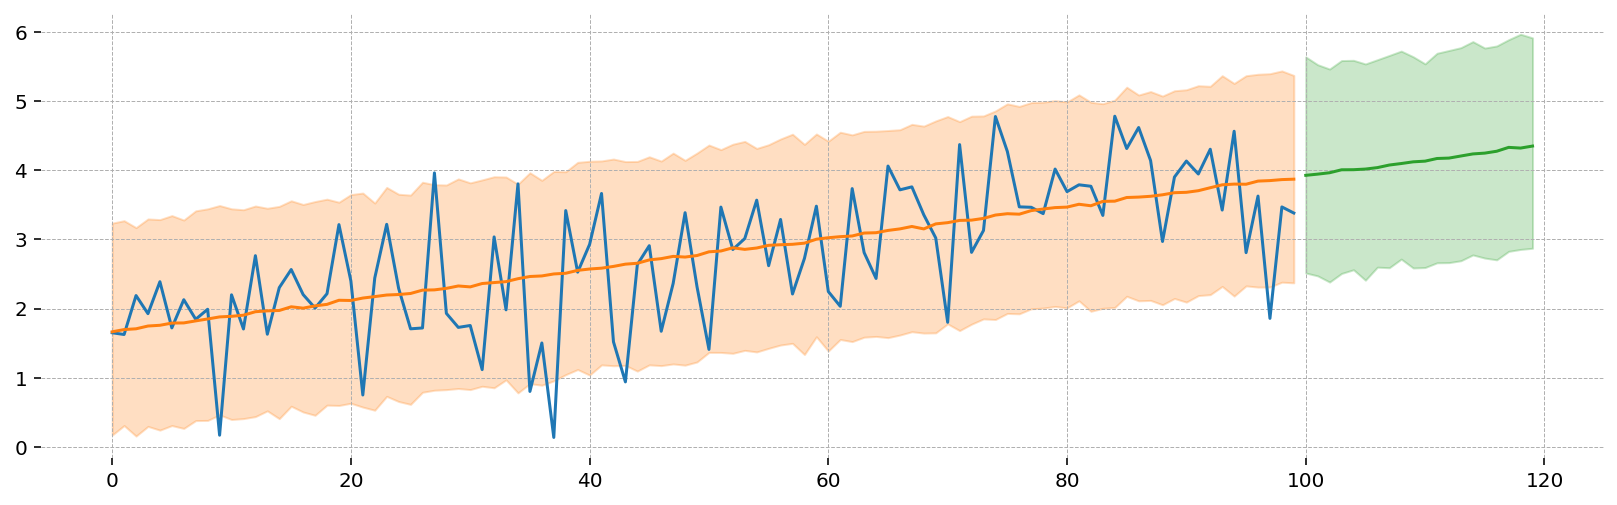

In [ ]:
# Xisualize your entire Bayesian workflow — observed data, model fit, and forecasted predictions

fig, ax = plt.subplots(figsize=(14, 4), dpi=144)
ax.plot(data)

mu = idata.posterior_predictive.y_hat.mean(dim=["chain", "draw"])
hdi = az.hdi(idata.posterior_predictive).y_hat

ax.plot(mu)
ax.fill_between(range(100), *hdi.values.T, color="tab:orange", alpha=0.25)

forecast_mu = forecast.predictions.y_hat.mean(dim=["chain", "draw"])
forecast_hdi = az.hdi(forecast.predictions).y_hat
ax.plot(range(100, 120), forecast_mu)
ax.fill_between(range(100, 120), *forecast_hdi.values.T, color="tab:green", alpha=0.25)
plt.show()

This example is extremely simple, but it can be extended in powerful ways by pumping time values of time through arbitrarily complex functions. Examples include the Prophet model, which transform the time counter into a time-varying trend and sinusoidal seasonal waves.

Gaussian Processes are another example -- these pump the time counter through a **kernel function**, and evaluates datapoints as "similar" or "different" based on their distance in the kernel space.

Time-as-feature models have a lot of advantages. At the end of the day, many of them are just basic linear projections (not GPs though). As such, they fit quickly, scale well, and can be trivially parallelized for minibatching and hardware acceleration. 

This example is about time-as-feature models.

# Moving from Deterministic to Stochastic Trends

Up to now, the model assumed a **straight linear trend**:

$$
\mu_t = \alpha + \beta t
$$

This is simple, but real-world time series **rarely follow perfect straight lines**.  
To handle more complex dynamics, we introduce **latent states** that evolve **stochastically** over time.

---

## **State Equation** *(hidden dynamics)*

$$
\mu_t = \mu_{t-1} + \eta_t, \qquad \eta_t \sim \mathcal{N}(0,\ \tau^2)
$$

- $\mu_t$ → hidden (latent) state at time $t$
- $\eta_t$ → Gaussian noise driving random fluctuations
- $\tau^2$ → variance controlling how much the state can "wander"

This is called a **Gaussian Random Walk**:  
the latent trend $\mu_t$ drifts gradually and unpredictably over time.

---

## **Observation Equation** *(how we see the data)*

$$
y_t = \mu_t + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\ \sigma^2)
$$

- $y_t$ → observed data at time $t$
- $\varepsilon_t$ → measurement noise
- $\sigma^2$ → variance of observation noise

---

## **Putting It Together: State-Space Model**

A **state-space model** combines two parts:

1. **State equation** → describes how the hidden process $\mu_t$ evolves.
2. **Observation equation** → links the hidden process to the noisy data $y_t$.

In other words:
- The model **learns** the hidden trajectory $\mu_t$.
- It explains how the observed data are generated from this hidden process.

---

## **Thinking in Systems**

Previously, the model looked like a **simple regression**:

- Few parameters: $\alpha$, $\beta$, $\sigma$
- Direct formula for predictions: $\mu_t = \alpha + \beta t$

But now, in the **Thinking in Systems** section, the model becomes **richer**:

- Instead of a single formula, the model **infers an entire trajectory**:
  
  $$
  \mu_1, \mu_2, \dots, \mu_T
  $$
  
- We no longer compute $\mu_t$ directly;  
  PyMC **estimates its distribution** at every time step.
- Instead of one fitted line, we now get a **distribution of possible paths**.

---

## **Key Shift in Mindset**

This section represents a big change:

**Point estimates** → **Probabilistic inference** → **Uncertainty modeling**

- **Before:** Estimate a few fixed numbers $(\alpha, \beta, \sigma)$.
- **Now:** Model entire **trajectories** $\mu_t$ with **credible intervals**.
- Instead of assuming one “true” trend,  
  the model learns a **family of plausible hidden dynamics**.


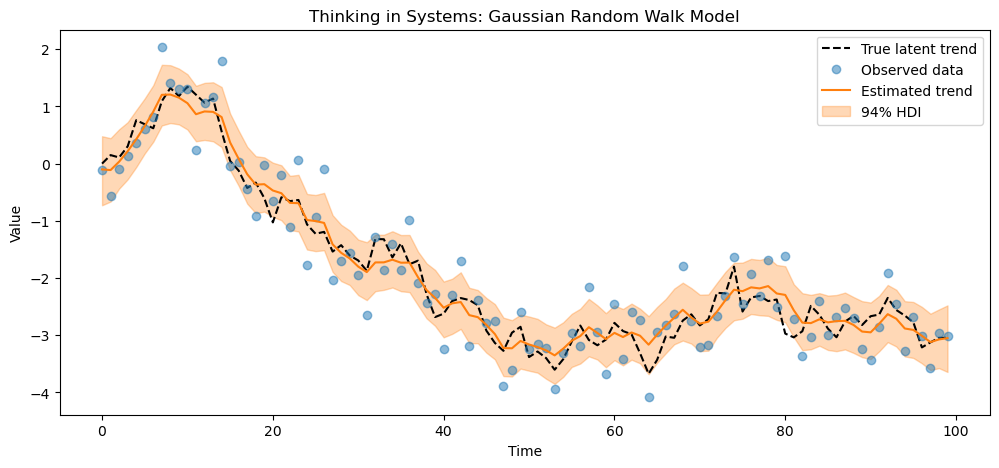

In [ ]:
# ---------------------------
# 1. Generate synthetic data
# ---------------------------
np.random.seed(42)
n = 100  # number of time steps
tau_true = 0.3      # true latent trend noise
sigma_true = 0.5    # observation noise

# Latent trend: Gaussian Random Walk
mu_true = np.zeros(n)
mu_true[0] = 0
for t in range(1, n):
    mu_true[t] = mu_true[t - 1] + np.random.normal(0, tau_true)

# Observed data: noisy measurements of latent trend
y = mu_true + np.random.normal(0, sigma_true, n)

# ---------------------------
# 2. Build the PyMC model
# ---------------------------
coords = {"time": np.arange(n)}

with pm.Model(coords=coords) as model:
    # Prior for latent states (Gaussian Random Walk)
    tau = pm.Exponential("tau", 1.0)
    mu = pm.GaussianRandomWalk("mu", sigma=tau, dims="time")
    
    # Observation noise
    sigma = pm.Exponential("sigma", 1.0)
    
    # Likelihood: observations are noisy measurements of mu
    y_hat = pm.Normal("y_hat", mu=mu, sigma=sigma, observed=y, dims="time")
    
    # Posterior sampling
    idata = pm.sample(target_accept=0.95, random_seed=42)
    
    
# Posterior mean of the latent state (DataArray with dim "time")
mu_posterior = idata.posterior["mu"].mean(dim=("chain", "draw"))

# HDI (can be DataArray or Dataset depending on ArviZ version)
hdi_xr = az.hdi(idata.posterior["mu"], hdi_prob=0.94)

# If ArviZ returns a Dataset, extract the "mu" variable
if isinstance(hdi_xr, xr.Dataset):
    hdi_da = hdi_xr["mu"]
else:
    hdi_da = hdi_xr  # already a DataArray

# Extract lower/upper bounds from HDI DataArray
lower = hdi_da.sel(hdi="lower").values
upper = hdi_da.sel(hdi="higher").values

# Time index
n = mu_posterior.sizes["time"]
t = np.arange(n)

# Plot the results
plt.figure(figsize=(12, 5))
if "mu_true" in globals():  # plot true latent trend if available
    plt.plot(mu_true, "k--", label="True latent trend")
if "y" in globals():        # plot observed data if available
    plt.plot(y, "o", alpha=0.5, label="Observed data")

plt.plot(t, mu_posterior, color="tab:orange", label="Estimated trend")
plt.fill_between(t, lower, upper, color="tab:orange", alpha=0.3, label="94% HDI")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Gaussian Random Walk Model")
plt.legend()
plt.show()


# Stacked SSM with a latent random-walk trend plus a seasonal component (via Fourier terms), and observation noise

Here we:
- Move beyond a single trend to stack components (trend + seasonality).
- Learn a latent trajectory for the trend (random walk).
- Learn seasonal structure via Fourier coefficients.
- Produce posterior predictive fit with uncertainty bands and a clean decomposition,

**Are we taking the data into account here?**

Yes. The curves below are **posterior** (i.e., **conditional on the data**):

- The **posterior predictive mean** (and its HDI) should track the observations.
- The **latent trend** `μ_t` and the **seasonal component** `s_t` are *components* of the signal; neither is expected to pass through the raw data by itself. The model’s mean for the observation is `μ_t + s_t`.

It’s useful to distinguish:

- **Unconditional (prior)** distributions: before seeing any data; often very wide.
- **Conditional (posterior / posterior predictive)** distributions: after updating with the data; typically tighter and better aligned with observations.

If your plot shows a mean that doesn’t follow the data and intervals that are too wide, you might be looking at **prior predictive** samples or at a **single component** (e.g., `μ_t`) rather than the full observation mean `μ_t + s_t`.


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [tau, mu, a, b, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_hat]


Output()

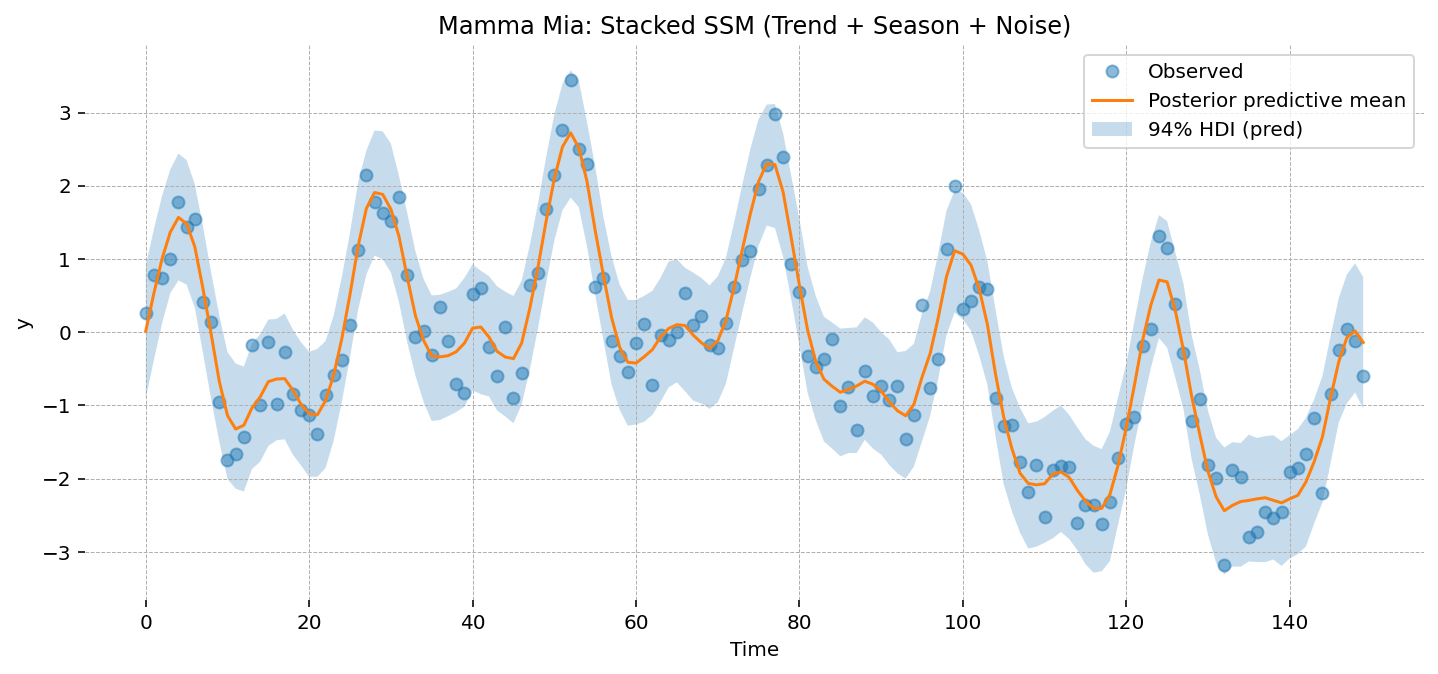

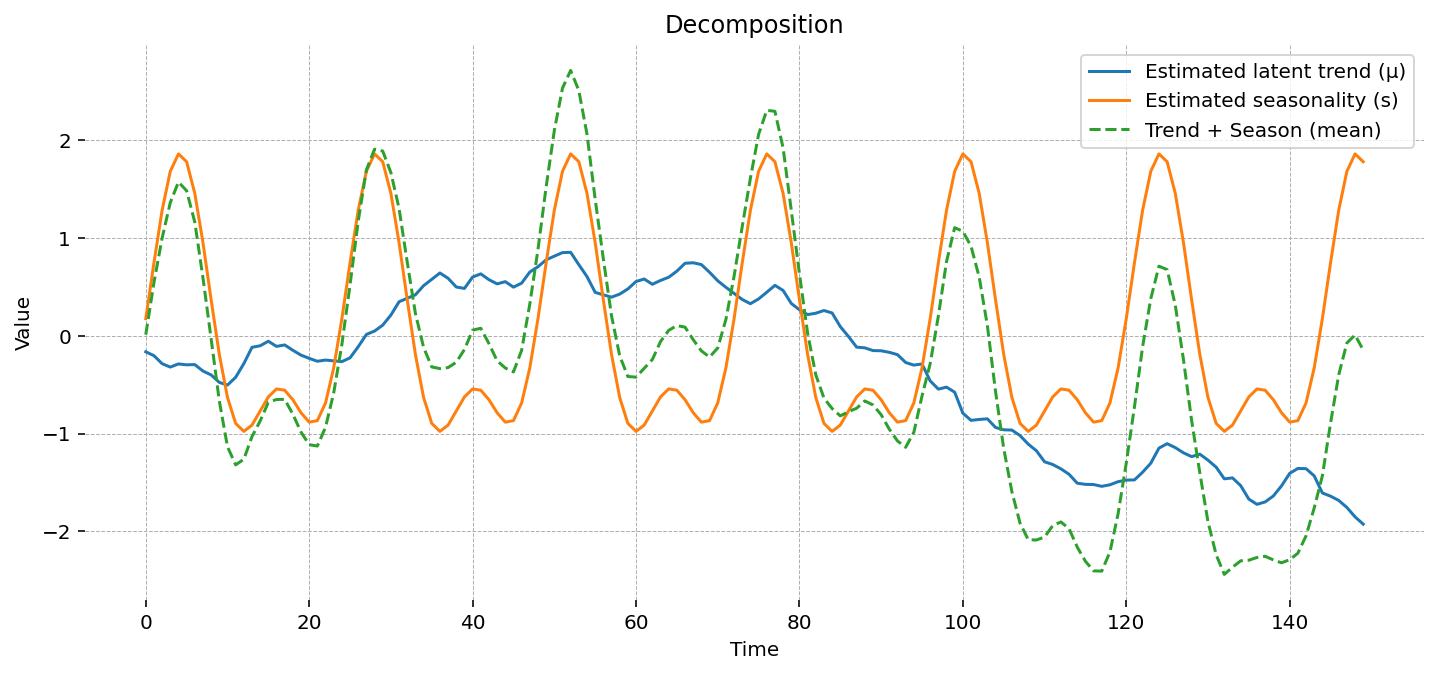

In [11]:
# --- Trend + Seasonality + Noise (Stacked SSM) ---

rng = np.random.default_rng(42)

# ---------------------------
# 1) Simulate data
# ---------------------------
n = 150
P = 24          # seasonal period (e.g., 24 hours / months / etc.)
K = 2           # number of Fourier harmonics
tau_mu_true = 0.20   # RW volatility for latent trend
sigma_true   = 0.40  # observation noise

# Latent trend: Gaussian Random Walk
mu_true = np.zeros(n)
for t in range(1, n):
    mu_true[t] = mu_true[t-1] + rng.normal(0, tau_mu_true)

# True seasonal signal (for simulation) using Fourier terms
t_idx = np.arange(n)
season_true = (
    1.0 * np.sin(2*np.pi*1*t_idx/P) + 0.5 * np.cos(2*np.pi*1*t_idx/P)
  + 0.6 * np.sin(2*np.pi*2*t_idx/P) - 0.3 * np.cos(2*np.pi*2*t_idx/P)
)

# Observations
y = mu_true + season_true + rng.normal(0, sigma_true, size=n)

# Build seasonal design matrices for modeling (n x K)
def seasonal_design(t, period, K):
    Xs = np.stack([np.sin(2*np.pi*k*t/period) for k in range(1, K+1)], axis=1)  # (n, K)
    Xc = np.stack([np.cos(2*np.pi*k*t/period) for k in range(1, K+1)], axis=1)  # (n, K)
    return Xs, Xc

Xs, Xc = seasonal_design(t_idx, P, K)

# ---------------------------
# 2) Build & fit the PyMC model
# ---------------------------
coords = {"time": t_idx, "harmonic": np.arange(1, K+1)}

with pm.Model(coords=coords) as mamma_mia:
    # Data nodes so we could swap design later if needed
    Xs_data = pm.Data("Xs", Xs, dims=("time", "harmonic"))
    Xc_data = pm.Data("Xc", Xc, dims=("time", "harmonic"))

    # Latent trend: Gaussian Random Walk
    tau = pm.Exponential("tau", 1.0)  # prior for RW volatility
    mu  = pm.GaussianRandomWalk("mu", sigma=tau, dims=("time",))

    # Seasonality via Fourier with learned coefficients
    a = pm.Normal("a", 0.0, 1.0, dims=("harmonic",))
    b = pm.Normal("b", 0.0, 1.0, dims=("harmonic",))
    season = pm.Deterministic(
        "season",
        (Xs_data * a).sum(axis=1) + (Xc_data * b).sum(axis=1),
        dims=("time",)
    )

    # Observation noise
    sigma = pm.Exponential("sigma", 1.0)

    # Observation model
    y_hat = pm.Normal("y_hat", mu=mu + season, sigma=sigma, observed=y, dims=("time",))

    idata = pm.sample(target_accept=0.95, random_seed=42)

# Posterior predictive for in-sample fit
with mamma_mia:
    idata = pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=42)

# ---------------------------
# 3) Plots: fit + decomposition
# ---------------------------

# Helper to extract HDI robustly (DataArray or Dataset)
def extract_hdi_da(hdi_obj, var_name=None):
    if isinstance(hdi_obj, xr.Dataset):
        if var_name is None:
            raise ValueError("Provide var_name when HDI is a Dataset.")
        da = hdi_obj[var_name]
    else:
        da = hdi_obj
    lower = da.sel(hdi="lower").values
    upper = da.sel(hdi="higher").values
    return lower, upper

# Posterior predictive fit (in-sample)
ppc_mean = idata.posterior_predictive["y_hat"].mean(dim=("chain", "draw"))
ppc_hdi  = az.hdi(idata.posterior_predictive["y_hat"], hdi_prob=0.94)
ppc_lo, ppc_hi = extract_hdi_da(ppc_hdi, var_name="y_hat")

# Latent trend & season posteriors
mu_post     = idata.posterior["mu"].mean(dim=("chain", "draw")).values
season_post = idata.posterior["season"].mean(dim=("chain", "draw")).values

# --- Figure 1: In-sample fit with HDI ---
plt.figure(figsize=(12, 5))
plt.plot(t_idx, y, "o", alpha=0.5, label="Observed")
plt.plot(t_idx, ppc_mean, label="Posterior predictive mean")
plt.fill_between(t_idx, ppc_lo, ppc_hi, alpha=0.25, label="94% HDI (pred)")
plt.title("Mamma Mia: Stacked SSM (Trend + Season + Noise)")
plt.xlabel("Time")
plt.ylabel("y")
plt.legend()
plt.show()

# --- Figure 2: Decomposition ---
plt.figure(figsize=(12, 5))
plt.plot(t_idx, mu_post, label="Estimated latent trend (μ)")
plt.plot(t_idx, season_post, label="Estimated seasonality (s)")
plt.plot(t_idx, mu_post + season_post, "--", label="Trend + Season (mean)")
plt.title("Decomposition")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()
